In [32]:
import pandapower as pp
import pandapower.networks as pn

net = pn.case14()
print(net)

This pandapower network includes the following parameter tables:
   - bus (14 elements)
   - load (11 elements)
   - gen (4 elements)
   - shunt (1 element)
   - ext_grid (1 element)
   - line (15 elements)
   - trafo (5 elements)
   - poly_cost (5 elements)


In [33]:
print("=== BUS (nœuds du graphe) ===")
print(net.bus)

print("\n=== LINE (arêtes du graphe) ===")
print(net.line)

print("\n=== LOAD (charges Pd, Qd) ===")
print(net.load)

print("\n=== GEN (générateurs) ===")
print(net.gen)

print("\n=== EXT_GRID (bus de référence / slack) ===")
print(net.ext_grid)

=== BUS (nœuds du graphe) ===
   name    vn_kv type zone  in_service  max_vm_pu  min_vm_pu  \
0     1  135.000    b  1.0        True       1.06       0.94   
1     2  135.000    b  1.0        True       1.06       0.94   
2     3  135.000    b  1.0        True       1.06       0.94   
3     4  135.000    b  1.0        True       1.06       0.94   
4     5  135.000    b  1.0        True       1.06       0.94   
5     6    0.208    b  1.0        True       1.06       0.94   
6     7   14.000    b  1.0        True       1.06       0.94   
7     8   12.000    b  1.0        True       1.06       0.94   
8     9    0.208    b  1.0        True       1.06       0.94   
9    10    0.208    b  1.0        True       1.06       0.94   
10   11    0.208    b  1.0        True       1.06       0.94   
11   12    0.208    b  1.0        True       1.06       0.94   
12   13    0.208    b  1.0        True       1.06       0.94   
13   14    0.208    b  1.0        True       1.06       0.94   

         

In [34]:
pp.runpp(net)
print(net.res_bus)   # Vm et Va calculés pour chaque bus

       vm_pu  va_degree        p_mw     q_mvar
0   1.060000   0.000000 -232.393272  16.549301
1   1.045000  -4.982589  -18.300000 -30.857100
2   1.010000 -12.725100   94.200000  -6.075348
3   1.017671 -10.312901   47.800000  -3.900000
4   1.019514  -8.773854    7.600000   1.600000
5   1.070000 -14.220946   11.200000  -5.230944
6   1.061520 -13.359627    0.000000   0.000000
7   1.090000 -13.359627    0.000000 -17.623451
8   1.055932 -14.938521   29.500000  -4.584844
9   1.050985 -15.097288    9.000000   5.800000
10  1.056907 -14.790622    3.500000   1.800000
11  1.055189 -15.075585    6.100000   1.600000
12  1.050382 -15.156276   13.500000   5.800000
13  1.035530 -16.033645   14.900000   5.000000


In [35]:
net = pn.case14()
original_p = net.load['p_mw'].copy()
original_q = net.load['q_mvar'].copy()

n_scenarios = 500
results = []

for i in range(n_scenarios):
    load_factor = np.random.uniform(0.8, 1.2)
    net.load['p_mw'] = original_p * load_factor
    net.load['q_mvar'] = original_q * load_factor

    try:
        pp.runpp(net)
        results.append({
            'scenario': i,
            'load_factor': load_factor,
            'pd_per_bus': net.res_bus['p_mw'].values.copy(),   # Pd réel par bus
            'qd_per_bus': net.res_bus['q_mvar'].values.copy(), # Qd réel par bus
            'vm': net.res_bus['vm_pu'].values.copy(),
            'va': net.res_bus['va_degree'].values.copy(),
        })
    except Exception as e:
        print(f"Scénario {i} a échoué : {e}")

print(f"{len(results)} scénarios générés avec succès sur {n_scenarios}")

500 scénarios générés avec succès sur 500


In [36]:
# Construire une matrice (n_scenarios x n_bus) pour Vm et pour Va
vm_matrix = np.array([r['vm'] for r in results])   # shape: (500, 14)
va_matrix = np.array([r['va'] for r in results])   # shape: (500, 14)
load_factors = np.array([r['load_factor'] for r in results])

print("Vm matrix shape:", vm_matrix.shape)
print("Va matrix shape:", va_matrix.shape)
print("Exemple - scénario 0:")
print("  load_factor:", load_factors[0])
print("  Vm:", vm_matrix[0])
print("  Va:", va_matrix[0])

Vm matrix shape: (500, 14)
Va matrix shape: (500, 14)
Exemple - scénario 0:
  load_factor: 0.8433417219301714
  Vm: [1.06       1.045      1.01       1.02201918 1.02354431 1.07
 1.06600481 1.09       1.06290209 1.05793205 1.060998   1.05792363
 1.05423322 1.04410511]
  Va: [  0.          -3.93798561 -10.36006137  -8.45065696  -7.16632539
 -11.68801562 -11.01938735 -11.01938735 -12.34762397 -12.47216938
 -12.19413637 -12.40736526 -12.48335785 -13.23984184]


In [37]:
import torch

# Récupérer les connexions bus-à-bus depuis net.line
from_bus = net.line['from_bus'].values
to_bus = net.line['to_bus'].values

print("Nombre de lignes (edges):", len(from_bus))
print("from_bus:", from_bus)
print("to_bus:", to_bus)

# PyTorch Geometric attend un graphe non orienté -> on ajoute les deux sens
edge_index = torch.tensor(
    np.vstack([
        np.concatenate([from_bus, to_bus]),
        np.concatenate([to_bus, from_bus])
    ]),
    dtype=torch.long
)

print("\nedge_index shape:", edge_index.shape)  # attendu: (2, 30) car 15 lignes x 2 sens
print(edge_index)

Nombre de lignes (edges): 15
from_bus: [ 0  0  1  1  1  2  3  5  5  5  8  8  9 11 12]
to_bus: [ 1  4  2  3  4  3  4 10 11 12  9 13 10 12 13]

edge_index shape: torch.Size([2, 30])
tensor([[ 0,  0,  1,  1,  1,  2,  3,  5,  5,  5,  8,  8,  9, 11, 12,  1,  4,  2,
          3,  4,  3,  4, 10, 11, 12,  9, 13, 10, 12, 13],
        [ 1,  4,  2,  3,  4,  3,  4, 10, 11, 12,  9, 13, 10, 12, 13,  0,  0,  1,
          1,  1,  2,  3,  5,  5,  5,  8,  8,  9, 11, 12]])


In [38]:
# Contraintes de tension par bus (fixes, ne dépendent pas du scénario)
vmax = net.bus['max_vm_pu'].values  # (14,)
vmin = net.bus['min_vm_pu'].values  # (14,)

# Type de bus : Slack = 0, PV (générateur) = 1, PQ (charge/transit) = 2
bus_type = np.full(len(net.bus), 2.0)  # tout le monde PQ par défaut
bus_type[net.ext_grid['bus'].values] = 0.0   # slack
bus_type[net.gen['bus'].values] = 1.0         # générateurs PV

print("vmax:", vmax)
print("vmin:", vmin)
print("bus_type:", bus_type)

vmax: [1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06]
vmin: [0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94 0.94]
bus_type: [0. 1. 1. 2. 2. 1. 2. 1. 2. 2. 2. 2. 2. 2.]


In [39]:
from torch_geometric.data import Data

dataset = []

for r in results:
    # Features des nœuds : [Pd, Qd, bus_type, Vmax, Vmin]
    x = np.stack([
        r['pd_per_bus'],
        r['qd_per_bus'],
        bus_type,
        vmax,
        vmin
    ], axis=1)  # shape: (14, 5)

    # Cible : [Vm, Va]
    y = np.stack([r['vm'], r['va']], axis=1)  # shape: (14, 2)

    data = Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=edge_index,
        y=torch.tensor(y, dtype=torch.float)
    )
    dataset.append(data)

print(f"Dataset construit : {len(dataset)} graphes")
print("Exemple - premier graphe :")
print(dataset[0])
print("x shape:", dataset[0].x.shape)
print("y shape:", dataset[0].y.shape)

Dataset construit : 500 graphes
Exemple - premier graphe :
Data(x=[14, 5], edge_index=[2, 30], y=[14, 2])
x shape: torch.Size([14, 5])
y shape: torch.Size([14, 2])


In [40]:
from torch_geometric.loader import DataLoader
import random

random.seed(42)
random.shuffle(dataset)

split_idx = int(0.8 * len(dataset))
train_dataset = dataset[:split_idx]
test_dataset = dataset[split_idx:]

print(f"Train: {len(train_dataset)} graphes")
print(f"Test: {len(test_dataset)} graphes")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Train: 400 graphes
Test: 100 graphes


In [41]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, in_channels=5, hidden_channels=64, out_channels=2):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.lin(x)
        return x

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(5, 64)
  (conv2): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [42]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
n_epochs = 100
train_losses = []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_dataset)
    train_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

print("Entraînement terminé.")

Epoch   0 | Loss: 32.1379
Epoch  10 | Loss: 1.0041
Epoch  20 | Loss: 0.5667
Epoch  30 | Loss: 0.4654
Epoch  40 | Loss: 0.3832
Epoch  50 | Loss: 0.3387
Epoch  60 | Loss: 0.3182
Epoch  70 | Loss: 0.3034
Epoch  80 | Loss: 0.3251
Epoch  90 | Loss: 0.2460
Entraînement terminé.


In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for batch in test_loader:
        out = model(batch.x, batch.edge_index)
        all_preds.append(out)
        all_targets.append(batch.y)

all_preds = torch.cat(all_preds, dim=0).numpy()
all_targets = torch.cat(all_targets, dim=0).numpy()

# Séparer Vm et Va
vm_pred, va_pred = all_preds[:, 0], all_preds[:, 1]
vm_true, va_true = all_targets[:, 0], all_targets[:, 1]

print("=== Voltage Magnitude (Vm) ===")
print(f"MAE:  {mean_absolute_error(vm_true, vm_pred):.5f}")
print(f"RMSE: {mean_squared_error(vm_true, vm_pred)**0.5:.5f}")
print(f"R²:   {r2_score(vm_true, vm_pred):.5f}")

print("\n=== Voltage Angle (Va) ===")
print(f"MAE:  {mean_absolute_error(va_true, va_pred):.5f}")
print(f"RMSE: {mean_squared_error(va_true, va_pred)**0.5:.5f}")
print(f"R²:   {r2_score(va_true, va_pred):.5f}")

=== Voltage Magnitude (Vm) ===
MAE:  0.05659
RMSE: 0.06147
R²:   -7.49836

=== Voltage Angle (Va) ===
MAE:  0.37822
RMSE: 0.64615
R²:   0.98073


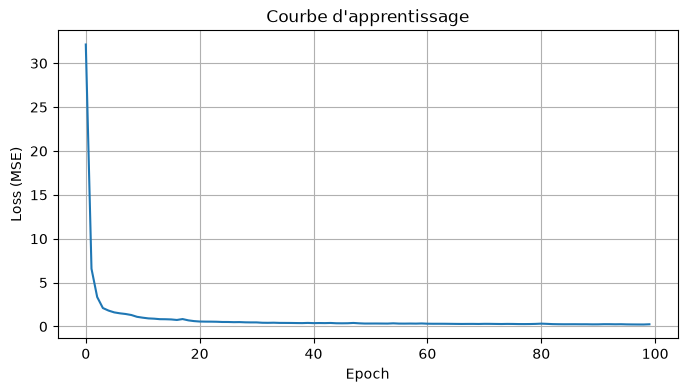

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Courbe d'apprentissage")
plt.grid(True)
plt.show()

In [45]:
# Récupérer toutes les features x et targets y du train set
train_x = torch.cat([d.x for d in train_dataset], dim=0).numpy()
train_y = torch.cat([d.y for d in train_dataset], dim=0).numpy()

x_mean, x_std = train_x.mean(axis=0), train_x.std(axis=0)
y_mean, y_std = train_y.mean(axis=0), train_y.std(axis=0)

# Éviter division par zéro (ex: bus_type, vmax, vmin sont presque constants)
x_std[x_std < 1e-6] = 1.0

print("x_mean:", x_mean)
print("x_std:", x_std)
print("y_mean (Vm, Va):", y_mean)
print("y_std (Vm, Va):", y_std)

x_mean: [-0.97354746 -2.2168603   1.5714285   1.060048    0.93995327]
x_std: [6.9862518e+01 1.1571922e+01 6.2270534e-01 4.8042479e-05 4.6730042e-05]
y_mean (Vm, Va): [  1.0484415 -12.057844 ]
y_std (Vm, Va): [0.02117114 4.756235  ]


In [66]:
# Reconstruire dataset (non normalisé) avec le nouveau edge_index
dataset = []

for r in results:
    x = np.stack([
        r['pd_per_bus'],
        r['qd_per_bus'],
        bus_type,
        vmax,
        vmin
    ], axis=1)

    y = np.stack([r['vm'], r['va']], axis=1)

    data = Data(
        x=torch.tensor(x, dtype=torch.float),
        edge_index=edge_index,   # <- le nouveau, avec les trafos
        y=torch.tensor(y, dtype=torch.float)
    )
    dataset.append(data)

print(f"Dataset reconstruit : {len(dataset)} graphes")
print("edge_index utilisé:", dataset[0].edge_index.shape)
random.seed(42)
random.shuffle(dataset)
split_idx = int(0.8 * len(dataset))
train_dataset = dataset[:split_idx]
test_dataset = dataset[split_idx:]

train_x = torch.cat([d.x for d in train_dataset], dim=0).numpy()
train_y = torch.cat([d.y for d in train_dataset], dim=0).numpy()

x_mean, x_std = train_x.mean(axis=0), train_x.std(axis=0)
y_mean, y_std = train_y.mean(axis=0), train_y.std(axis=0)
x_std[x_std < 1e-6] = 1.0

dataset_norm = []
for d in dataset:
    x_norm = (d.x.numpy() - x_mean) / x_std
    y_norm = (d.y.numpy() - y_mean) / y_std
    dataset_norm.append(Data(
        x=torch.tensor(x_norm, dtype=torch.float),
        edge_index=edge_index,
        y=torch.tensor(y_norm, dtype=torch.float)
    ))

random.seed(42)
random.shuffle(dataset_norm)
train_dataset_norm = dataset_norm[:split_idx]
test_dataset_norm = dataset_norm[split_idx:]

train_loader_norm = DataLoader(train_dataset_norm, batch_size=32, shuffle=True)
test_loader_norm = DataLoader(test_dataset_norm, batch_size=32, shuffle=False)

print(f"Train: {len(train_dataset_norm)}, Test: {len(test_dataset_norm)}")

Dataset reconstruit : 500 graphes
edge_index utilisé: torch.Size([2, 40])
Train: 400, Test: 100


In [67]:
model_norm = GCN()
optimizer = torch.optim.Adam(model_norm.parameters(), lr=0.01)
n_epochs = 100
train_losses_norm = []

for epoch in range(n_epochs):
    model_norm.train()
    total_loss = 0
    for batch in train_loader_norm:
        optimizer.zero_grad()
        out = model_norm(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_dataset_norm)
    train_losses_norm.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

Epoch   0 | Loss: 0.6730
Epoch  10 | Loss: 0.0513
Epoch  20 | Loss: 0.0125
Epoch  30 | Loss: 0.0023
Epoch  40 | Loss: 0.0015
Epoch  50 | Loss: 0.0017
Epoch  60 | Loss: 0.0014
Epoch  70 | Loss: 0.0016
Epoch  80 | Loss: 0.0013
Epoch  90 | Loss: 0.0008


In [68]:
model_norm.eval()
all_preds_norm, all_targets_norm = [], []

with torch.no_grad():
    for batch in test_loader_norm:
        out = model_norm(batch.x, batch.edge_index)
        all_preds_norm.append(out)
        all_targets_norm.append(batch.y)

all_preds_norm = torch.cat(all_preds_norm, dim=0).numpy()
all_targets_norm = torch.cat(all_targets_norm, dim=0).numpy()

# Dénormaliser pour revenir aux unités réelles (pu et degrés)
preds_denorm = all_preds_norm * y_std + y_mean
targets_denorm = all_targets_norm * y_std + y_mean

vm_pred, va_pred = preds_denorm[:, 0], preds_denorm[:, 1]
vm_true, va_true = targets_denorm[:, 0], targets_denorm[:, 1]

print("=== Voltage Magnitude (Vm) ===")
print(f"MAE:  {mean_absolute_error(vm_true, vm_pred):.5f}")
print(f"RMSE: {mean_squared_error(vm_true, vm_pred)**0.5:.5f}")
print(f"R²:   {r2_score(vm_true, vm_pred):.5f}")

print("\n=== Voltage Angle (Va) ===")
print(f"MAE:  {mean_absolute_error(va_true, va_pred):.5f}")
print(f"RMSE: {mean_squared_error(va_true, va_pred)**0.5:.5f}")
print(f"R²:   {r2_score(va_true, va_pred):.5f}")

=== Voltage Magnitude (Vm) ===
MAE:  0.00057
RMSE: 0.00069
R²:   0.99893

=== Voltage Angle (Va) ===
MAE:  0.16177
RMSE: 0.18690
R²:   0.99844


Nombre de bus : 14
Nombre total de branches : 20
Nombre de composantes : 1


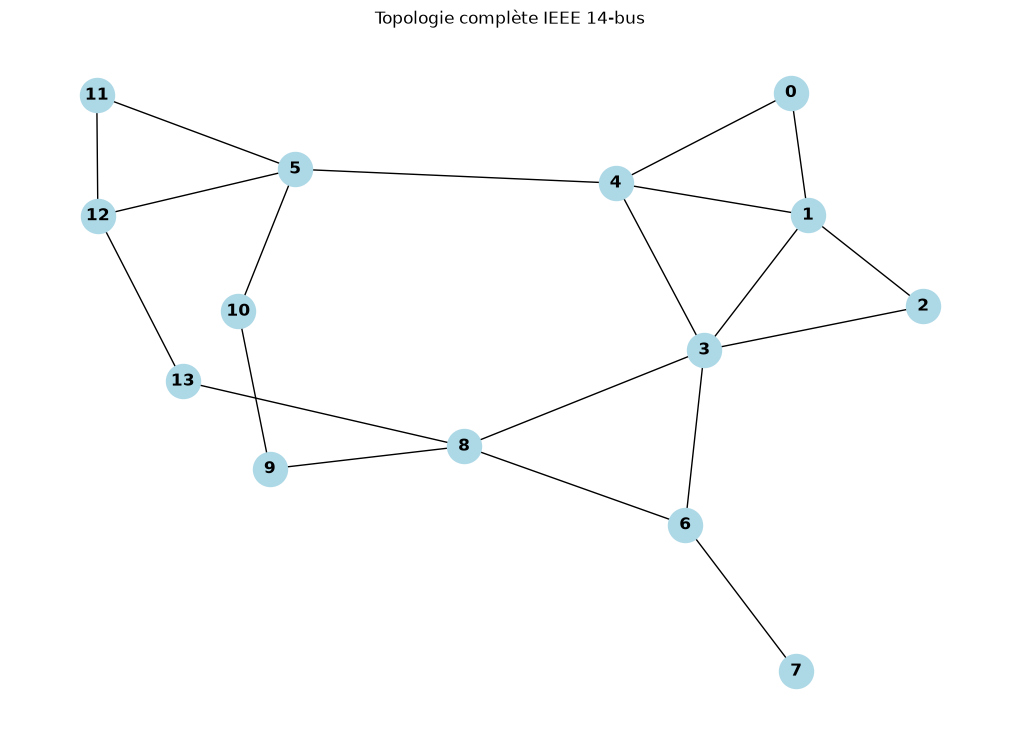

In [71]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Ajouter les 14 bus
G.add_nodes_from(range(len(net.bus)))

# Ajouter les lignes
line_edges = list(
    zip(
        net.line["from_bus"],
        net.line["to_bus"]
    )
)

# Ajouter les transformateurs
trafo_edges = list(
    zip(
        net.trafo["hv_bus"],
        net.trafo["lv_bus"]
    )
)

# Ajouter toutes les connexions
G.add_edges_from(line_edges)
G.add_edges_from(trafo_edges)

print("Nombre de bus :", G.number_of_nodes())
print("Nombre total de branches :", G.number_of_edges())
print("Nombre de composantes :", nx.number_connected_components(G))

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 7))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=600,
    font_weight="bold"
)

plt.title("Topologie complète IEEE 14-bus")
plt.show()

In [50]:
print(from_bus)
print(to_bus)

[ 0  0  1  1  1  2  3  5  5  5  8  8  9 11 12]
[ 1  4  2  3  4  3  4 10 11 12  9 13 10 12 13]


In [51]:
print(list(zip(from_bus, to_bus)))

[(np.uint32(0), np.uint32(1)), (np.uint32(0), np.uint32(4)), (np.uint32(1), np.uint32(2)), (np.uint32(1), np.uint32(3)), (np.uint32(1), np.uint32(4)), (np.uint32(2), np.uint32(3)), (np.uint32(3), np.uint32(4)), (np.uint32(5), np.uint32(10)), (np.uint32(5), np.uint32(11)), (np.uint32(5), np.uint32(12)), (np.uint32(8), np.uint32(9)), (np.uint32(8), np.uint32(13)), (np.uint32(9), np.uint32(10)), (np.uint32(11), np.uint32(12)), (np.uint32(12), np.uint32(13))]


In [52]:
print("Nombre de bus :", len(net.bus))
print("Nombre de lignes :", len(net.line))

print("\n--- net.line ---")
print(net.line[['from_bus', 'to_bus']])

Nombre de bus : 14
Nombre de lignes : 15

--- net.line ---
    from_bus  to_bus
0          0       1
1          0       4
2          1       2
3          1       3
4          1       4
5          2       3
6          3       4
7          5      10
8          5      11
9          5      12
10         8       9
11         8      13
12         9      10
13        11      12
14        12      13


In [53]:
print("Nombre de bus :", len(net.bus))
print("Nombre de lignes :", len(net.line))

print("\n--- net.line ---")
print(net.line[['from_bus', 'to_bus']])

Nombre de bus : 14
Nombre de lignes : 15

--- net.line ---
    from_bus  to_bus
0          0       1
1          0       4
2          1       2
3          1       3
4          1       4
5          2       3
6          3       4
7          5      10
8          5      11
9          5      12
10         8       9
11         8      13
12         9      10
13        11      12
14        12      13


In [54]:
print("Nombre de edges :", len(list(zip(from_bus, to_bus))))

Nombre de edges : 15


In [55]:
print(net.trafo[['hv_bus', 'lv_bus']])

   hv_bus  lv_bus
0       3       6
1       3       8
2       4       5
3       6       7
4       6       8


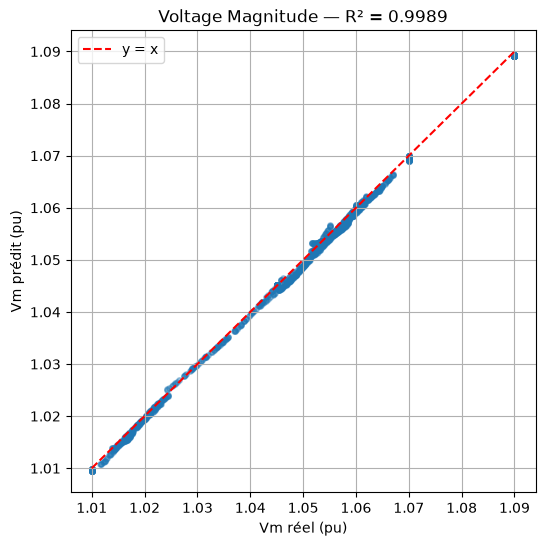

In [72]:
plt.figure(figsize=(6, 6))
plt.scatter(vm_true, vm_pred, alpha=0.4, s=15)
plt.plot([vm_true.min(), vm_true.max()], [vm_true.min(), vm_true.max()], 'r--', label='y = x')
plt.xlabel("Vm réel (pu)")
plt.ylabel("Vm prédit (pu)")
plt.title(f"Voltage Magnitude — R² = {r2_score(vm_true, vm_pred):.4f}")
plt.legend()
plt.grid(True)
plt.show()

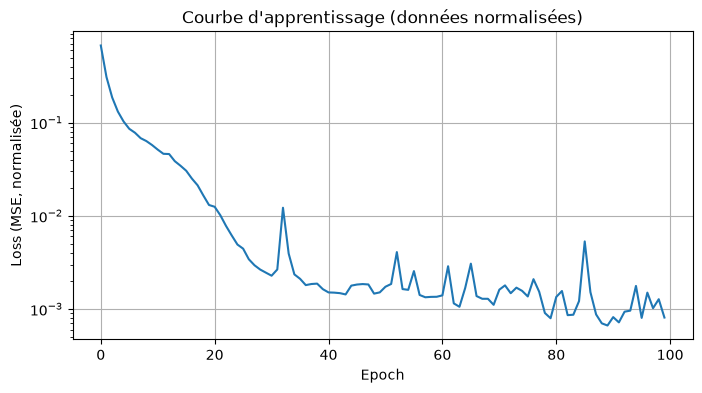

In [73]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses_norm)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE, normalisée)")
plt.title("Courbe d'apprentissage (données normalisées)")
plt.grid(True)
plt.yscale('log')
plt.show()

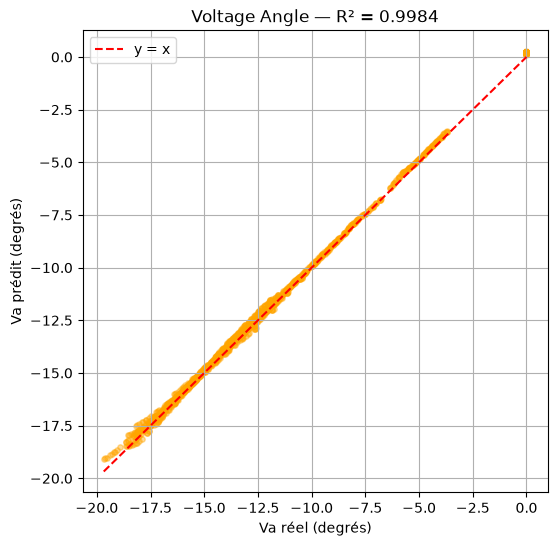

In [74]:
plt.figure(figsize=(6, 6))
plt.scatter(va_true, va_pred, alpha=0.4, s=15, color='orange')
plt.plot([va_true.min(), va_true.max()], [va_true.min(), va_true.max()], 'r--', label='y = x')
plt.xlabel("Va réel (degrés)")
plt.ylabel("Va prédit (degrés)")
plt.title(f"Voltage Angle — R² = {r2_score(va_true, va_pred):.4f}")
plt.legend()
plt.grid(True)
plt.show()

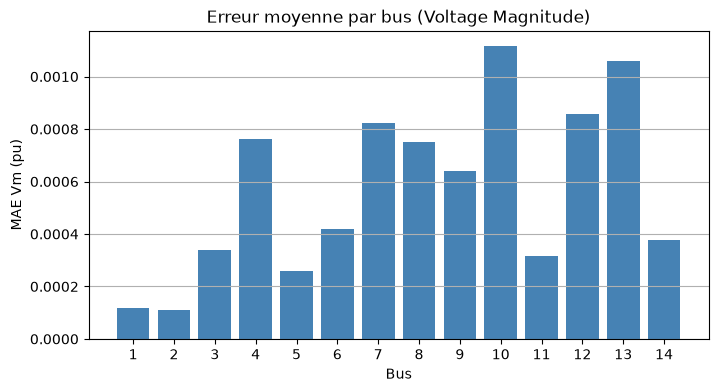

In [75]:
# Nombre de scénarios dans le test set
n_test = len(test_dataset_norm)
n_bus = 14

# Réorganiser les prédictions en matrice (n_scenarios x n_bus)
vm_pred_matrix = vm_pred.reshape(n_test, n_bus)
vm_true_matrix = vm_true.reshape(n_test, n_bus)

# Erreur absolue moyenne, par bus
mae_per_bus = np.abs(vm_pred_matrix - vm_true_matrix).mean(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(range(1, n_bus + 1), mae_per_bus, color='steelblue')
plt.xlabel("Bus")
plt.ylabel("MAE Vm (pu)")
plt.title("Erreur moyenne par bus (Voltage Magnitude)")
plt.xticks(range(1, n_bus + 1))
plt.grid(True, axis='y')
plt.show()

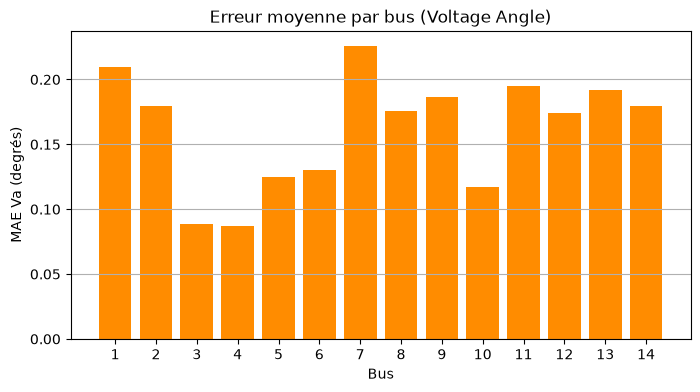

In [76]:
va_pred_matrix = va_pred.reshape(n_test, n_bus)
va_true_matrix = va_true.reshape(n_test, n_bus)
mae_per_bus_va = np.abs(va_pred_matrix - va_true_matrix).mean(axis=0)

plt.figure(figsize=(8, 4))
plt.bar(range(1, n_bus + 1), mae_per_bus_va, color='darkorange')
plt.xlabel("Bus")
plt.ylabel("MAE Va (degrés)")
plt.title("Erreur moyenne par bus (Voltage Angle)")
plt.xticks(range(1, n_bus + 1))
plt.grid(True, axis='y')
plt.show()

In [61]:
print(vm_pred.shape[0] == n_test * n_bus)

True


In [62]:
print(net.trafo[['hv_bus', 'lv_bus']])

   hv_bus  lv_bus
0       3       6
1       3       8
2       4       5
3       6       7
4       6       8


In [63]:
# Connexions des lignes
line_from = net.line['from_bus'].values
line_to = net.line['to_bus'].values

# Connexions des transformateurs
trafo_from = net.trafo['hv_bus'].values
trafo_to = net.trafo['lv_bus'].values

# Combiner les deux types de connexions
all_from = np.concatenate([line_from, trafo_from])
all_to = np.concatenate([line_to, trafo_to])

print("Nombre total de connexions (lignes + trafos):", len(all_from))  # doit faire 20

# Graphe non orienté : les deux sens
edge_index = torch.tensor(
    np.vstack([
        np.concatenate([all_from, all_to]),
        np.concatenate([all_to, all_from])
    ]),
    dtype=torch.long
)

print("Nouveau edge_index shape:", edge_index.shape)  # attendu: (2, 40)

Nombre total de connexions (lignes + trafos): 20
Nouveau edge_index shape: torch.Size([2, 40])


In [79]:
net = pn.case14()
original_p = net.load['p_mw'].copy()
original_q = net.load['q_mvar'].copy()

def generate_scenarios(n_scenarios, factor_range):
    scenarios = []
    for i in range(n_scenarios):
        load_factor = np.random.uniform(*factor_range)
        net.load['p_mw'] = original_p * load_factor
        net.load['q_mvar'] = original_q * load_factor
        try:
            pp.runpp(net)
            scenarios.append({
                'load_factor': load_factor,
                'pd_per_bus': net.res_bus['p_mw'].values.copy(),
                'qd_per_bus': net.res_bus['q_mvar'].values.copy(),
                'vm': net.res_bus['vm_pu'].values.copy(),
                'va': net.res_bus['va_degree'].values.copy(),
            })
        except Exception as e:
            print(f"Échec: {e}")
    return scenarios

results_train_range = generate_scenarios(500, (0.8, 1.1))
results_ood_test = generate_scenarios(150, (1.1, 1.2))

print(f"Train range: {len(results_train_range)} scénarios")
print(f"OOD test: {len(results_ood_test)} scénarios")

Train range: 500 scénarios
OOD test: 150 scénarios


In [80]:
def build_dataset(results_list, edge_index):
    ds = []
    for r in results_list:
        x = np.stack([
            r['pd_per_bus'],
            r['qd_per_bus'],
            bus_type,
            vmax,
            vmin
        ], axis=1)
        y = np.stack([r['vm'], r['va']], axis=1)
        ds.append(Data(
            x=torch.tensor(x, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor(y, dtype=torch.float)
        ))
    return ds

# Dataset dans la plage d'entraînement (0.8-1.1)
dataset_range = build_dataset(results_train_range, edge_index)

# Split interne : 80% train, 20% test "in-distribution" (même plage 0.8-1.1)
random.seed(42)
random.shuffle(dataset_range)
split_idx = int(0.8 * len(dataset_range))
train_dataset_ood = dataset_range[:split_idx]
test_dataset_indist = dataset_range[split_idx:]  # test "classique", même distribution

# Dataset complètement hors distribution (1.1-1.2), jamais vu à l'entraînement
test_dataset_ood = build_dataset(results_ood_test, edge_index)

print(f"Train: {len(train_dataset_ood)}")
print(f"Test in-distribution: {len(test_dataset_indist)}")
print(f"Test out-of-distribution: {len(test_dataset_ood)}")

Train: 400
Test in-distribution: 100
Test out-of-distribution: 150


In [81]:
train_x = torch.cat([d.x for d in train_dataset_ood], dim=0).numpy()
train_y = torch.cat([d.y for d in train_dataset_ood], dim=0).numpy()

x_mean_ood, x_std_ood = train_x.mean(axis=0), train_x.std(axis=0)
y_mean_ood, y_std_ood = train_y.mean(axis=0), train_y.std(axis=0)
x_std_ood[x_std_ood < 1e-6] = 1.0

def normalize_dataset(ds, x_mean, x_std, y_mean, y_std, edge_index):
    ds_norm = []
    for d in ds:
        x_norm = (d.x.numpy() - x_mean) / x_std
        y_norm = (d.y.numpy() - y_mean) / y_std
        ds_norm.append(Data(
            x=torch.tensor(x_norm, dtype=torch.float),
            edge_index=edge_index,
            y=torch.tensor(y_norm, dtype=torch.float)
        ))
    return ds_norm

train_dataset_ood_norm = normalize_dataset(train_dataset_ood, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood, edge_index)
test_dataset_indist_norm = normalize_dataset(test_dataset_indist, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood, edge_index)
test_dataset_ood_norm = normalize_dataset(test_dataset_ood, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood, edge_index)

train_loader_ood = DataLoader(train_dataset_ood_norm, batch_size=32, shuffle=True)
test_loader_indist = DataLoader(test_dataset_indist_norm, batch_size=32, shuffle=False)
test_loader_ood = DataLoader(test_dataset_ood_norm, batch_size=32, shuffle=False)

print("Loaders prêts.") 

Loaders prêts.


In [82]:
model_ood = GCN()
optimizer = torch.optim.Adam(model_ood.parameters(), lr=0.01)
n_epochs = 100
train_losses_ood = []

for epoch in range(n_epochs):
    model_ood.train()
    total_loss = 0
    for batch in train_loader_ood:
        optimizer.zero_grad()
        out = model_ood(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_dataset_ood_norm)
    train_losses_ood.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

Epoch   0 | Loss: 0.6924
Epoch  10 | Loss: 0.0467
Epoch  20 | Loss: 0.0153
Epoch  30 | Loss: 0.0071
Epoch  40 | Loss: 0.0036
Epoch  50 | Loss: 0.0024
Epoch  60 | Loss: 0.0013
Epoch  70 | Loss: 0.0014
Epoch  80 | Loss: 0.0018
Epoch  90 | Loss: 0.0015


In [83]:
def evaluate(model, loader, x_mean, x_std, y_mean, y_std):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch.x, batch.edge_index)
            all_preds.append(out)
            all_targets.append(batch.y)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    preds_denorm = all_preds * y_std + y_mean
    targets_denorm = all_targets * y_std + y_mean

    vm_p, va_p = preds_denorm[:, 0], preds_denorm[:, 1]
    vm_t, va_t = targets_denorm[:, 0], targets_denorm[:, 1]

    return {
        'vm_mae': mean_absolute_error(vm_t, vm_p),
        'vm_rmse': mean_squared_error(vm_t, vm_p)**0.5,
        'vm_r2': r2_score(vm_t, vm_p),
        'va_mae': mean_absolute_error(va_t, va_p),
        'va_rmse': mean_squared_error(va_t, va_p)**0.5,
        'va_r2': r2_score(va_t, va_p),
    }

metrics_indist = evaluate(model_ood, test_loader_indist, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)
metrics_ood = evaluate(model_ood, test_loader_ood, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)

print("=== Test IN-DISTRIBUTION (load factor 0.8-1.1, jamais vu mais même plage) ===")
for k, v in metrics_indist.items():
    print(f"  {k}: {v:.5f}")

print("\n=== Test OUT-OF-DISTRIBUTION (load factor 1.1-1.2, plage jamais vue à l'entraînement) ===")
for k, v in metrics_ood.items():
    print(f"  {k}: {v:.5f}")

print("\n=== Dégradation relative (OOD vs in-distribution) ===")
for metric in ['vm_mae', 'vm_rmse', 'va_mae', 'va_rmse']:
    degradation = (metrics_ood[metric] - metrics_indist[metric]) / metrics_indist[metric] * 100
    print(f"  {metric}: {degradation:+.1f}%")

=== Test IN-DISTRIBUTION (load factor 0.8-1.1, jamais vu mais même plage) ===
  vm_mae: 0.00046
  vm_rmse: 0.00058
  vm_r2: 0.99923
  va_mae: 0.13241
  va_rmse: 0.15668
  va_r2: 0.99871

=== Test OUT-OF-DISTRIBUTION (load factor 1.1-1.2, plage jamais vue à l'entraînement) ===
  vm_mae: 0.00172
  vm_rmse: 0.00221
  vm_r2: 0.98968
  va_mae: 0.86845
  va_rmse: 1.07720
  va_r2: 0.95743

=== Dégradation relative (OOD vs in-distribution) ===
  vm_mae: +271.7%
  vm_rmse: +281.2%
  va_mae: +555.9%
  va_rmse: +587.5%


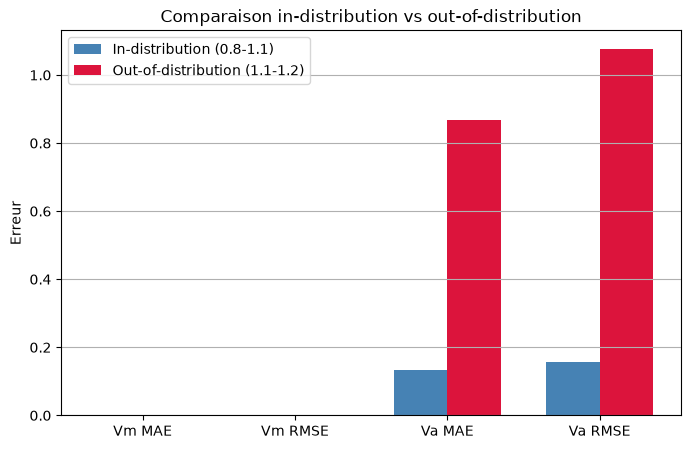

In [84]:
import numpy as np

metrics_names = ['Vm MAE', 'Vm RMSE', 'Va MAE', 'Va RMSE']
indist_vals = [metrics_indist['vm_mae'], metrics_indist['vm_rmse'], metrics_indist['va_mae'], metrics_indist['va_rmse']]
ood_vals = [metrics_ood['vm_mae'], metrics_ood['vm_rmse'], metrics_ood['va_mae'], metrics_ood['va_rmse']]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, indist_vals, width, label='In-distribution (0.8-1.1)', color='steelblue')
ax.bar(x + width/2, ood_vals, width, label='Out-of-distribution (1.1-1.2)', color='crimson')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel("Erreur")
ax.set_title("Comparaison in-distribution vs out-of-distribution")
ax.legend()
ax.grid(True, axis='y')
plt.show()

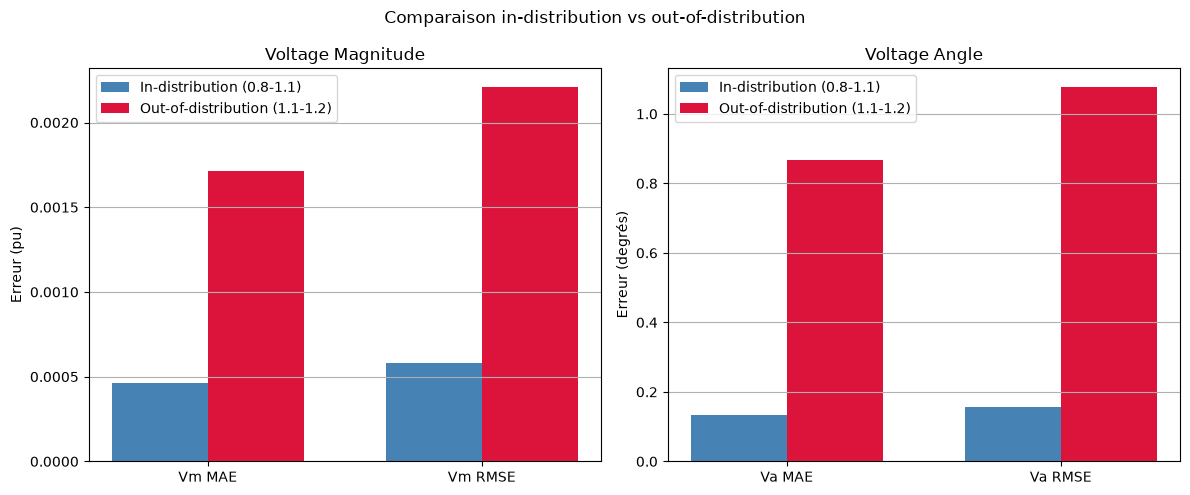

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Vm
metrics_vm = ['Vm MAE', 'Vm RMSE']
indist_vm = [metrics_indist['vm_mae'], metrics_indist['vm_rmse']]
ood_vm = [metrics_ood['vm_mae'], metrics_ood['vm_rmse']]

x_vm = np.arange(len(metrics_vm))
width = 0.35

axes[0].bar(x_vm - width/2, indist_vm, width, label='In-distribution (0.8-1.1)', color='steelblue')
axes[0].bar(x_vm + width/2, ood_vm, width, label='Out-of-distribution (1.1-1.2)', color='crimson')
axes[0].set_xticks(x_vm)
axes[0].set_xticklabels(metrics_vm)
axes[0].set_ylabel("Erreur (pu)")
axes[0].set_title("Voltage Magnitude")
axes[0].legend()
axes[0].grid(True, axis='y')

# Va
metrics_va = ['Va MAE', 'Va RMSE']
indist_va = [metrics_indist['va_mae'], metrics_indist['va_rmse']]
ood_va = [metrics_ood['va_mae'], metrics_ood['va_rmse']]

x_va = np.arange(len(metrics_va))

axes[1].bar(x_va - width/2, indist_va, width, label='In-distribution (0.8-1.1)', color='steelblue')
axes[1].bar(x_va + width/2, ood_va, width, label='Out-of-distribution (1.1-1.2)', color='crimson')
axes[1].set_xticks(x_va)
axes[1].set_xticklabels(metrics_va)
axes[1].set_ylabel("Erreur (degrés)")
axes[1].set_title("Voltage Angle")
axes[1].legend()
axes[1].grid(True, axis='y')

plt.suptitle("Comparaison in-distribution vs out-of-distribution")
plt.tight_layout()
plt.show()

In [86]:
from torch_geometric.nn import GATConv

class GAT(torch.nn.Module):
    def __init__(self, in_channels=5, hidden_channels=64, out_channels=2, heads=4):
        super().__init__()
        # heads = nombre de "têtes d'attention" en parallèle (comme dans les Transformers)
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, concat=True)
        # après concat=True, la sortie a une taille hidden_channels * heads
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False)
        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)  # ELU est l'activation classique utilisée avec GAT (papier original)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = self.lin(x)
        return x

model_gat = GAT()
print(model_gat)

GAT(
  (conv1): GATConv(5, 64, heads=4)
  (conv2): GATConv(256, 64, heads=1)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [87]:
optimizer_gat = torch.optim.Adam(model_gat.parameters(), lr=0.01)
n_epochs = 100
train_losses_gat = []

for epoch in range(n_epochs):
    model_gat.train()
    total_loss = 0
    for batch in train_loader_ood:
        optimizer_gat.zero_grad()
        out = model_gat(batch.x, batch.edge_index)
        loss = F.mse_loss(out, batch.y)
        loss.backward()
        optimizer_gat.step()
        total_loss += loss.item() * batch.num_graphs

    avg_loss = total_loss / len(train_dataset_ood_norm)
    train_losses_gat.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f}")

Epoch   0 | Loss: 0.7051
Epoch  10 | Loss: 0.0380
Epoch  20 | Loss: 0.0069
Epoch  30 | Loss: 0.0036
Epoch  40 | Loss: 0.0039
Epoch  50 | Loss: 0.0020
Epoch  60 | Loss: 0.0010
Epoch  70 | Loss: 0.0020
Epoch  80 | Loss: 0.0028
Epoch  90 | Loss: 0.0035


In [88]:
metrics_gat_indist = evaluate(model_gat, test_loader_indist, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)
metrics_gat_ood = evaluate(model_gat, test_loader_ood, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)

print("=== GAT — Test IN-DISTRIBUTION ===")
for k, v in metrics_gat_indist.items():
    print(f"  {k}: {v:.5f}")

print("\n=== GAT — Test OUT-OF-DISTRIBUTION ===")
for k, v in metrics_gat_ood.items():
    print(f"  {k}: {v:.5f}")

=== GAT — Test IN-DISTRIBUTION ===
  vm_mae: 0.00036
  vm_rmse: 0.00045
  vm_r2: 0.99953
  va_mae: 0.07295
  va_rmse: 0.09158
  va_r2: 0.99956

=== GAT — Test OUT-OF-DISTRIBUTION ===
  vm_mae: 0.00128
  vm_rmse: 0.00202
  vm_r2: 0.99133
  va_mae: 0.18057
  va_rmse: 0.23063
  va_r2: 0.99805


In [89]:
import pandas as pd

comparison = pd.DataFrame({
    'GCN (in-dist)': metrics_indist,
    'GAT (in-dist)': metrics_gat_indist,
    'GCN (OOD)': metrics_ood,
    'GAT (OOD)': metrics_gat_ood,
}).T

print(comparison.round(5))

                vm_mae  vm_rmse    vm_r2   va_mae  va_rmse    va_r2
GCN (in-dist)  0.00046  0.00058  0.99923  0.13241  0.15668  0.99871
GAT (in-dist)  0.00036  0.00045  0.99953  0.07295  0.09158  0.99956
GCN (OOD)      0.00172  0.00221  0.98968  0.86845  1.07720  0.95743
GAT (OOD)      0.00128  0.00202  0.99133  0.18057  0.23063  0.99805


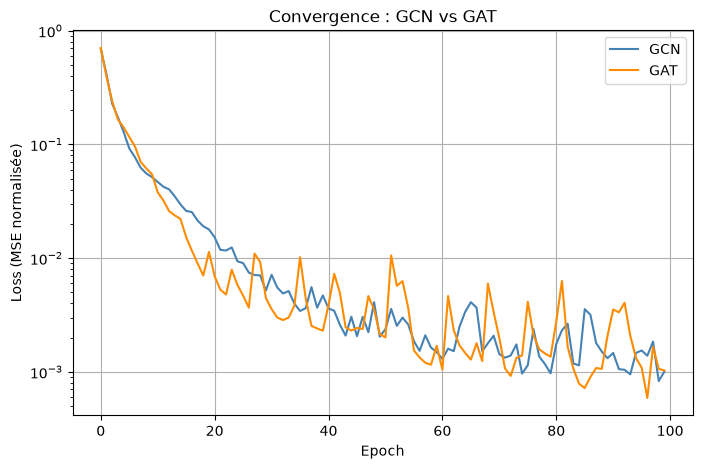

In [90]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_ood, label='GCN', color='steelblue')
plt.plot(train_losses_gat, label='GAT', color='darkorange')
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE normalisée)")
plt.yscale('log')
plt.title("Convergence : GCN vs GAT")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
import time

def measure_inference_time(model, loader, n_repeats=10):
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(n_repeats):
            start = time.perf_counter()
            for batch in loader:
                _ = model(batch.x, batch.edge_index)
            times.append(time.perf_counter() - start)
    return np.mean(times), np.std(times)

gcn_time, gcn_std = measure_inference_time(model_ood, test_loader_indist)
gat_time, gat_std = measure_inference_time(model_gat, test_loader_indist)

print(f"GCN : {gcn_time*1000:.2f} ms ± {gcn_std*1000:.2f} ms (sur {len(test_dataset_indist_norm)} graphes)")
print(f"GAT : {gat_time*1000:.2f} ms ± {gat_std*1000:.2f} ms (sur {len(test_dataset_indist_norm)} graphes)")

GCN : 51.56 ms ± 31.93 ms (sur 100 graphes)
GAT : 43.68 ms ± 10.16 ms (sur 100 graphes)


In [92]:
metrics_gat_indist = evaluate(model_gat, test_loader_indist, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)
metrics_gat_ood = evaluate(model_gat, test_loader_ood, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)

print("=== GAT — Test IN-DISTRIBUTION ===")
for k, v in metrics_gat_indist.items():
    print(f"  {k}: {v:.5f}")

print("\n=== GAT — Test OUT-OF-DISTRIBUTION ===")
for k, v in metrics_gat_ood.items():
    print(f"  {k}: {v:.5f}")

=== GAT — Test IN-DISTRIBUTION ===
  vm_mae: 0.00036
  vm_rmse: 0.00045
  vm_r2: 0.99953
  va_mae: 0.07295
  va_rmse: 0.09158
  va_r2: 0.99956

=== GAT — Test OUT-OF-DISTRIBUTION ===
  vm_mae: 0.00128
  vm_rmse: 0.00202
  vm_r2: 0.99133
  va_mae: 0.18057
  va_rmse: 0.23063
  va_r2: 0.99805


In [93]:
import pandas as pd

comparison = pd.DataFrame({
    'GCN (in-dist)': metrics_indist,
    'GAT (in-dist)': metrics_gat_indist,
    'GCN (OOD)': metrics_ood,
    'GAT (OOD)': metrics_gat_ood,
}).T

print(comparison.round(5))

                vm_mae  vm_rmse    vm_r2   va_mae  va_rmse    va_r2
GCN (in-dist)  0.00046  0.00058  0.99923  0.13241  0.15668  0.99871
GAT (in-dist)  0.00036  0.00045  0.99953  0.07295  0.09158  0.99956
GCN (OOD)      0.00172  0.00221  0.98968  0.86845  1.07720  0.95743
GAT (OOD)      0.00128  0.00202  0.99133  0.18057  0.23063  0.99805


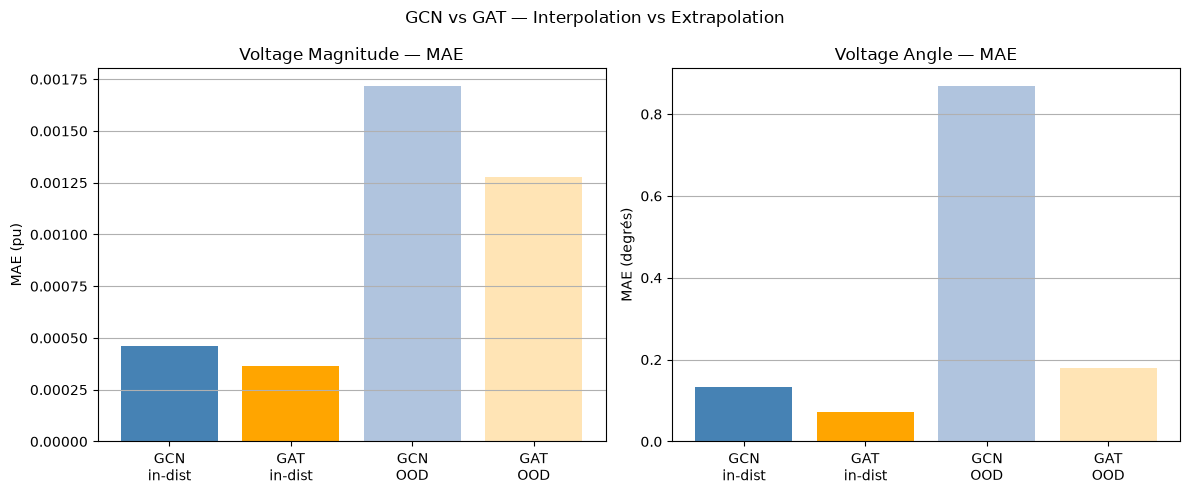

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['GCN\nin-dist', 'GAT\nin-dist', 'GCN\nOOD', 'GAT\nOOD']
colors = ['steelblue', 'orange', 'lightsteelblue', 'moccasin']

vm_maes = [metrics_indist['vm_mae'], metrics_gat_indist['vm_mae'],
           metrics_ood['vm_mae'], metrics_gat_ood['vm_mae']]
va_maes = [metrics_indist['va_mae'], metrics_gat_indist['va_mae'],
           metrics_ood['va_mae'], metrics_gat_ood['va_mae']]

axes[0].bar(models, vm_maes, color=colors)
axes[0].set_ylabel("MAE (pu)")
axes[0].set_title("Voltage Magnitude — MAE")
axes[0].grid(True, axis='y')

axes[1].bar(models, va_maes, color=colors)
axes[1].set_ylabel("MAE (degrés)")
axes[1].set_title("Voltage Angle — MAE")
axes[1].grid(True, axis='y')

plt.suptitle("GCN vs GAT — Interpolation vs Extrapolation")
plt.tight_layout()
plt.show()

In [95]:
net = pn.case14()
print(net.poly_cost)


   element        et  cp0_eur  cp1_eur_per_mw  cp2_eur_per_mw2  cq0_eur  \
0        0  ext_grid      0.0            20.0         0.043029      0.0   
1        0       gen      0.0            20.0         0.250000      0.0   
2        1       gen      0.0            40.0         0.010000      0.0   
3        2       gen      0.0            40.0         0.010000      0.0   
4        3       gen      0.0            40.0         0.010000      0.0   

   cq1_eur_per_mvar  cq2_eur_per_mvar2  
0               0.0                0.0  
1               0.0                0.0  
2               0.0                0.0  
3               0.0                0.0  
4               0.0                0.0  


In [96]:
net_opf = pn.case14()

pp.runopp(net_opf)

print("=== Résultat de l'OPF ===")
print("\nGénération (gen) :")
print(net_opf.res_gen[['p_mw', 'q_mvar']])

print("\nSlack (ext_grid) :")
print(net_opf.res_ext_grid[['p_mw', 'q_mvar']])

print("\nCoût total :", net_opf.res_cost, "€")

print("\nTensions résultantes (res_bus) :")
print(net_opf.res_bus[['vm_pu', 'va_degree']])

gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


=== Résultat de l'OPF ===

Génération (gen) :
        p_mw     q_mvar
0  36.719156  23.685095
1  28.742518  24.126876
2   0.000757  11.545314
3   8.494789   8.272970

Slack (ext_grid) :
         p_mw    q_mvar
0  194.329973  0.000796

Coût total : 8081.52661382886 €

Tensions résultantes (res_bus) :
       vm_pu  va_degree
0   1.060000   0.000000
1   1.040753  -4.022311
2   1.015625  -9.925920
3   1.014461  -8.664874
4   1.016362  -7.428420
5   1.059999 -12.689180
6   1.046346 -11.187882
7   1.059999 -10.414863
8   1.043698 -12.997147
9   1.039136 -13.232882
10  1.046008 -13.090924
11  1.044819 -13.532674
12  1.039948 -13.582527
13  1.023888 -14.274080


In [97]:
# Power flow classique avec génération par défaut
net_naive = pn.case14()
pp.runpp(net_naive)

# Calculer le coût de CETTE génération avec la même fonction de coût
def compute_cost(net):
    total = 0
    for _, row in net.poly_cost.iterrows():
        if row['et'] == 'gen':
            p = net.res_gen.loc[row['element'], 'p_mw']
        elif row['et'] == 'ext_grid':
            p = net.res_ext_grid.loc[row['element'], 'p_mw']
        cost = row['cp0_eur'] + row['cp1_eur_per_mw'] * p + row['cp2_eur_per_mw2'] * p**2
        total += cost
    return total

cost_naive = compute_cost(net_naive)
print(f"Coût (génération par défaut, non optimisée) : {cost_naive:.2f} €")
print(f"Coût (OPF) : {net_opf.res_cost:.2f} €")
print(f"Économie réalisée par l'OPF : {cost_naive - net_opf.res_cost:.2f} € ({(cost_naive - net_opf.res_cost)/cost_naive*100:.1f}%)")

Coût (génération par défaut, non optimisée) : 8171.73 €
Coût (OPF) : 8081.53 €
Économie réalisée par l'OPF : 90.21 € (1.1%)


In [98]:
def check_violations(vm_pred, vmin, vmax):
    """Vérifie si les tensions prédites violent les contraintes."""
    violations_low = vm_pred < vmin
    violations_high = vm_pred > vmax
    n_violations = violations_low.sum() + violations_high.sum()
    return n_violations > 0, n_violations

# Test sur les prédictions du GNN (in-distribution) déjà calculées
n_test = len(test_dataset_indist_norm)
n_bus = 14
vm_pred_matrix_gnn = vm_pred.reshape(n_test, n_bus)  # <- réutilise les prédictions GCN d'avant

violation_count = 0
for i in range(n_test):
    has_violation, n_viol = check_violations(vm_pred_matrix_gnn[i], vmin, vmax)
    if has_violation:
        violation_count += 1

print(f"Scénarios avec violation détectée par le GNN : {violation_count} / {n_test}")

Scénarios avec violation détectée par le GNN : 100 / 100


In [99]:
import time

def gnn_predict(model, x_raw, edge_index, x_mean, x_std, y_mean, y_std):
    """Prédiction rapide du GNN pour un seul scénario."""
    x_norm = (x_raw - x_mean) / x_std
    x_tensor = torch.tensor(x_norm, dtype=torch.float)
    with torch.no_grad():
        out = model(x_tensor, edge_index)
    out_denorm = out.numpy() * y_std + y_mean
    return out_denorm[:, 0], out_denorm[:, 1]  # vm, va

# Générer quelques nouveaux scénarios de test (pas encore vus)
net_pipeline = pn.case14()
original_p = net_pipeline.load['p_mw'].copy()
original_q = net_pipeline.load['q_mvar'].copy()

n_pipeline_tests = 30
gnn_times, opf_times = [], []
opf_triggered = 0

for i in range(n_pipeline_tests):
    load_factor = np.random.uniform(0.8, 1.3)  # plage large, y compris situations tendues
    net_pipeline.load['p_mw'] = original_p * load_factor
    net_pipeline.load['q_mvar'] = original_q * load_factor

    # 1. Power flow rapide pour obtenir Pd/Qd réels (features d'entrée du GNN)
    try:
        pp.runpp(net_pipeline)
    except:
        continue

    x_raw = np.stack([
        net_pipeline.res_bus['p_mw'].values,
        net_pipeline.res_bus['q_mvar'].values,
        bus_type,
        vmax,
        vmin
    ], axis=1)

    # 2. Prédiction GNN (rapide)
    t0 = time.perf_counter()
    vm_p, va_p = gnn_predict(model_ood, x_raw, edge_index, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)
    gnn_time = time.perf_counter() - t0
    gnn_times.append(gnn_time)

    # 3. Vérifier violation
    has_violation, n_viol = check_violations(vm_p, vmin, vmax)

    if has_violation:
        # 4. Si violation détectée -> lancer l'OPF complet (lent mais fiable)
        t0 = time.perf_counter()
        try:
            pp.runopp(net_pipeline)
            opf_triggered += 1
        except Exception as e:
            print(f"Scénario {i}: OPF a échoué - {e}")
        opf_time = time.perf_counter() - t0
        opf_times.append(opf_time)
        print(f"Scénario {i} (load_factor={load_factor:.2f}) : VIOLATION détectée ({n_viol} bus) -> OPF déclenché")
    else:
        print(f"Scénario {i} (load_factor={load_factor:.2f}) : OK, pas de violation -> GNN suffit")

print(f"\n=== Résumé ===")
print(f"Scénarios testés : {n_pipeline_tests}")
print(f"OPF déclenché : {opf_triggered} fois ({opf_triggered/n_pipeline_tests*100:.1f}%)")
print(f"Temps moyen GNN : {np.mean(gnn_times)*1000:.3f} ms")
if opf_times:
    print(f"Temps moyen OPF (quand déclenché) : {np.mean(opf_times)*1000:.1f} ms")

gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 0 (load_factor=0.84) : VIOLATION détectée (6 bus) -> OPF déclenché


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 1 (load_factor=0.86) : VIOLATION détectée (6 bus) -> OPF déclenché


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


...

Scénario 27 (load_factor=0.80) : VIOLATION détectée (7 bus) -> OPF déclenché


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 28 (load_factor=1.09) : VIOLATION détectée (3 bus) -> OPF déclenché


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 29 (load_factor=1.18) : VIOLATION détectée (3 bus) -> OPF déclenché

=== Résumé ===
Scénarios testés : 30
OPF déclenché : 30 fois (100.0%)
Temps moyen GNN : 4.355 ms
Temps moyen OPF (quand déclenché) : 522.9 ms


In [100]:
# Regarde à quel point les prédictions sont proches des limites
for i in range(5):
    load_factor = np.random.uniform(0.8, 1.3)
    net_pipeline.load['p_mw'] = original_p * load_factor
    net_pipeline.load['q_mvar'] = original_q * load_factor
    pp.runpp(net_pipeline)

    x_raw = np.stack([
        net_pipeline.res_bus['p_mw'].values,
        net_pipeline.res_bus['q_mvar'].values,
        bus_type, vmax, vmin
    ], axis=1)

    vm_p, va_p = gnn_predict(model_ood, x_raw, edge_index, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)

    print(f"load_factor={load_factor:.2f}")
    print("  vm_pred:", np.round(vm_p, 4))
    print("  vmax:   ", vmax)
    print("  écart au max:", np.round(vmax - vm_p, 4))
    print()

load_factor=0.94
  vm_pred: [1.0607 1.0457 1.0102 1.0202 1.0215 1.0707 1.0635 1.0901 1.0591 1.0537
 1.0589 1.0563 1.0524 1.0396]
  vmax:    [1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06]
  écart au max: [-0.0007  0.0143  0.0498  0.0398  0.0385 -0.0107 -0.0035 -0.0301  0.0009
  0.0063  0.0011  0.0037  0.0076  0.0204]

load_factor=0.89
  vm_pred: [1.0606 1.0457 1.0103 1.0214 1.0228 1.0707 1.0646 1.0902 1.0614 1.0558
 1.0603 1.0569 1.0541 1.0421]
  vmax:    [1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06]
  écart au max: [-0.0006  0.0143  0.0497  0.0386  0.0372 -0.0107 -0.0046 -0.0302 -0.0014
  0.0042 -0.0003  0.0031  0.0059  0.0179]

load_factor=1.20
  vm_pred: [1.0627 1.0461 1.0103 1.0127 1.0198 1.0672 1.057  1.0869 1.046  1.0433
 1.0554 1.0586 1.0481 1.0271]
  vmax:    [1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06 1.06]
  écart au max: [-0.0027  0.0139  0.0497  0.0473  0.0402 -0.0072  0.003  -0.0269  0.014
  0.0167  0.

In [101]:
# Identifier les bus PQ (charge) vs PV/slack (générateurs)
pq_bus_mask = (bus_type == 2.0)  # rappel: 2.0 = PQ, 1.0 = PV, 0.0 = slack
print("Bus PQ (à surveiller):", np.where(pq_bus_mask)[0])
print("Bus PV/slack (contrôlés, exclus de la vérification):", np.where(~pq_bus_mask)[0])

def check_violations_pq_only(vm_pred, vmin, vmax, pq_mask, margin=0.005):
    """Ne vérifie les violations que sur les bus de charge (PQ)."""
    vm_pq = vm_pred[pq_mask]
    vmin_pq = vmin[pq_mask]
    vmax_pq = vmax[pq_mask]
    violations = (vm_pq < vmin_pq - margin) | (vm_pq > vmax_pq + margin)
    return violations.sum() > 0, violations.sum()

Bus PQ (à surveiller): [ 3  4  6  8  9 10 11 12 13]
Bus PV/slack (contrôlés, exclus de la vérification): [0 1 2 5 7]


In [102]:
n_pipeline_tests = 30
gnn_times, opf_times = [], []
opf_triggered = 0

for i in range(n_pipeline_tests):
    load_factor = np.random.uniform(0.8, 1.3)
    net_pipeline.load['p_mw'] = original_p * load_factor
    net_pipeline.load['q_mvar'] = original_q * load_factor

    try:
        pp.runpp(net_pipeline)
    except:
        continue

    x_raw = np.stack([
        net_pipeline.res_bus['p_mw'].values,
        net_pipeline.res_bus['q_mvar'].values,
        bus_type, vmax, vmin
    ], axis=1)

    t0 = time.perf_counter()
    vm_p, va_p = gnn_predict(model_ood, x_raw, edge_index, x_mean_ood, x_std_ood, y_mean_ood, y_std_ood)
    gnn_times.append(time.perf_counter() - t0)

    has_violation, n_viol = check_violations_pq_only(vm_p, vmin, vmax, pq_bus_mask, margin=0.005)

    if has_violation:
        t0 = time.perf_counter()
        try:
            pp.runopp(net_pipeline)
            opf_triggered += 1
        except Exception as e:
            print(f"Scénario {i}: OPF a échoué - {e}")
        opf_times.append(time.perf_counter() - t0)
        print(f"Scénario {i} (load_factor={load_factor:.2f}) : VIOLATION bus charge ({n_viol}) -> OPF")
    else:
        print(f"Scénario {i} (load_factor={load_factor:.2f}) : OK -> GNN suffit")

print(f"\n=== Résumé ===")
print(f"OPF déclenché : {opf_triggered}/{n_pipeline_tests} ({opf_triggered/n_pipeline_tests*100:.1f}%)")
print(f"Temps moyen GNN : {np.mean(gnn_times)*1000:.3f} ms")
if opf_times:
    print(f"Temps moyen OPF : {np.mean(opf_times)*1000:.1f} ms")

Scénario 0 (load_factor=0.99) : OK -> GNN suffit


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 1 (load_factor=0.87) : VIOLATION bus charge (1) -> OPF


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 2 (load_factor=0.87) : VIOLATION bus charge (1) -> OPF
Scénario 3 (load_factor=1.18) : OK -> GNN suffit
Scénario 4 (load_factor=0.97) : OK -> GNN suffit
Scénario 5 (load_factor=1.08) : OK -> GNN suffit


...

Scénario 25 (load_factor=0.83) : VIOLATION bus charge (1) -> OPF
Scénario 26 (load_factor=0.94) : OK -> GNN suffit
Scénario 27 (load_factor=1.07) : OK -> GNN suffit


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 28 (load_factor=0.83) : VIOLATION bus charge (1) -> OPF


gen vm_pu > bus max_vm_pu for gens [2 3]. Setting bus limit for these gens.


Scénario 29 (load_factor=0.82) : VIOLATION bus charge (1) -> OPF

=== Résumé ===
OPF déclenché : 8/30 (26.7%)
Temps moyen GNN : 7.582 ms
Temps moyen OPF : 360.9 ms


In [103]:
naive_total_time = n_pipeline_tests * np.mean(opf_times)
pipeline_total_time = n_pipeline_tests * np.mean(gnn_times) + opf_triggered * np.mean(opf_times)

print(f"Temps total (OPF systématique) : {naive_total_time:.1f} ms")
print(f"Temps total (pipeline GNN + OPF conditionnel) : {pipeline_total_time:.1f} ms")
print(f"Gain de temps : {(1 - pipeline_total_time/naive_total_time)*100:.1f}%")

Temps total (OPF systématique) : 10.8 ms
Temps total (pipeline GNN + OPF conditionnel) : 3.1 ms
Gain de temps : 71.2%


C:\Users\bougu\AppData\Local\Temp\ipykernel_22028\3890627340.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


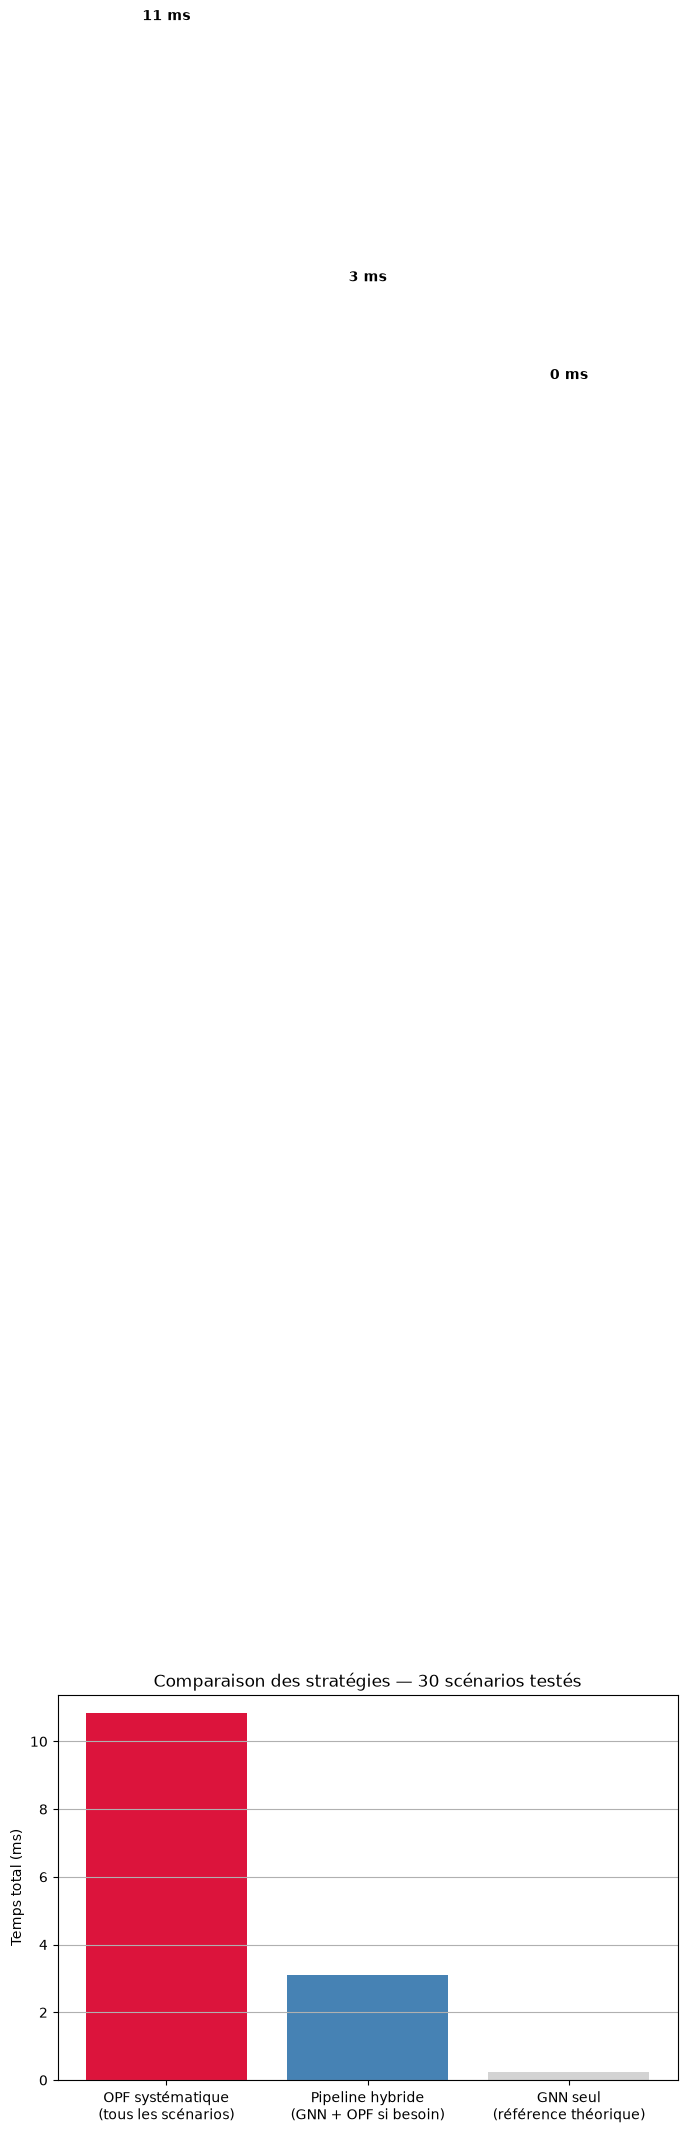

Gain du pipeline hybride vs OPF systématique : 71.2%


In [104]:
naive_total_time = n_pipeline_tests * np.mean(opf_times)
pipeline_total_time = n_pipeline_tests * np.mean(gnn_times) + opf_triggered * np.mean(opf_times)
gnn_only_total = n_pipeline_tests * np.mean(gnn_times)

approaches = ['OPF systématique\n(tous les scénarios)', 'Pipeline hybride\n(GNN + OPF si besoin)', 'GNN seul\n(référence théorique)']
times = [naive_total_time, pipeline_total_time, gnn_only_total]
colors = ['crimson', 'steelblue', 'lightgray']

plt.figure(figsize=(8, 5))
bars = plt.bar(approaches, times, color=colors)
plt.ylabel("Temps total (ms)")
plt.title(f"Comparaison des stratégies — {n_pipeline_tests} scénarios testés")
plt.grid(True, axis='y')

for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, t + 50, f"{t:.0f} ms", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Gain du pipeline hybride vs OPF systématique : {(1 - pipeline_total_time/naive_total_time)*100:.1f}%")